In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import os
import pandas as pd
SCRIPTS = Path().resolve() / ".."
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as constants
import utils

%matplotlib inline

In [3]:
from astropy.io import ascii
from astropy.utils.data import download_file
import urllib.request

urllib.request.urlretrieve("https://cdsarc.cds.unistra.fr/ftp/J/AJ/137/3100/table3.dat", "table3.dat")
urllib.request.urlretrieve("https://cdsarc.cds.unistra.fr/ftp/J/AJ/137/3100/ReadMe", "ReadMe")

t = ascii.read("table3.dat", readme="ReadMe", format='cds')

t['FeH'] =  1.76 * t['SigFe'] - 2.11
from astropy.coordinates import SkyCoord
import astropy.units as u

sign = np.where(t['DE-'] == '-', -1, 1)

coords = SkyCoord(
    ra=15 * (t['RAh'].value + t['RAm'].value/60 + t['RAs'].value/3600),
    dec=sign * (t['DEd'].value + t['DEm'].value/60 + t['DEs'].value/3600),
    unit=u.deg
)

t['RA_DEG']  = coords.ra.deg
t['DEC_DEG'] = coords.dec.deg

# Fornax center
ra_center  = 15 * (2 + 39/60 + 59.3/3600) 
dec_center = -(34 + 26/60 + 57/3600)

t['radius']= np.sqrt((t['RA_DEG'] - ra_center)**2 * np.cos(np.radians(dec_center))**2 + (t['DEC_DEG'] - dec_center)**2)

In [4]:
np.random.seed(42)

tdown = t#[np.random.choice(len(t), size=200, replace=False)]
v_mu = np.mean(tdown['HV'])
v_std = np.std(tdown['HV'])
mask = np.abs(tdown['HV'] - v_mu) < 3 * v_std
tdown = tdown[mask]

In [4]:
R_proj = tdown['radius']
vlos = tdown['HV']-np.mean(t['HV'])
vlos_err = tdown['e_HV']

vdisp_binned_res = utils.calc_vdisp_los_binned(
    R_proj, vlos, vlos_err,
    ntracer_per_bin=50)

100%|██████████| 2000/2000 [00:02<00:00, 870.21it/s]


Autocorrelation times: [23.3106143  20.98896763]
Mean tau: 22.1 steps (total chain: 2000 steps)
Discarded 69 steps, thinned by 10
Final sample size: 1544


100%|██████████| 2000/2000 [00:02<00:00, 887.86it/s]


Autocorrelation times: [26.58680399 19.47554047]
Mean tau: 23.0 steps (total chain: 2000 steps)
Discarded 79 steps, thinned by 9
Final sample size: 1704


100%|██████████| 2000/2000 [00:02<00:00, 824.37it/s]


...

Autocorrelation times: [17.91554895 19.37102745]
Mean tau: 18.6 steps (total chain: 2000 steps)
Discarded 58 steps, thinned by 8
Final sample size: 1936


100%|██████████| 2000/2000 [00:02<00:00, 851.85it/s]


Autocorrelation times: [19.20320413 11.92670425]
Mean tau: 15.6 steps (total chain: 2000 steps)
Discarded 57 steps, thinned by 5
Final sample size: 3104


100%|██████████| 2000/2000 [00:02<00:00, 889.70it/s]

Autocorrelation times: [21.11423717 25.93333711]
Mean tau: 23.5 steps (total chain: 2000 steps)
Discarded 77 steps, thinned by 10
Final sample size: 1536


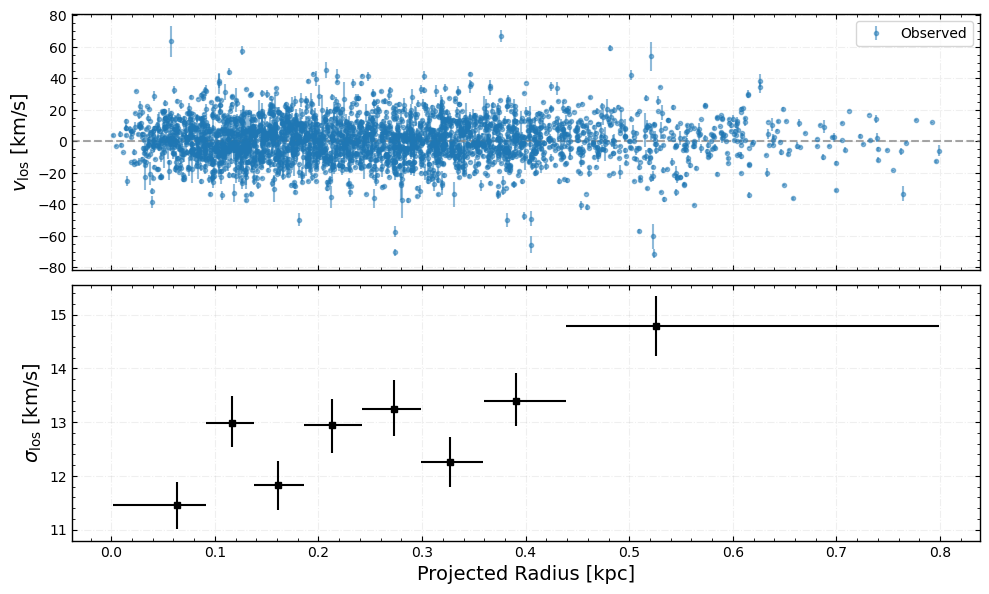

In [5]:
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True, tight_layout=True)

axes[0].errorbar(R_proj, vlos, yerr=vlos_err, fmt='o', markersize=3, alpha=0.5, label='Observed')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_ylabel(r'$v_\mathrm{los}$ [km/s]', fontsize=14)

# plot the binned velocity dispersion
R_mid = vdisp_binned_res['R_mid']
R_em = vdisp_binned_res['R_em']
R_ep = vdisp_binned_res['R_ep']
sigma = vdisp_binned_res['sigma']
sigma_em = vdisp_binned_res['sigma_em']
sigma_ep = vdisp_binned_res['sigma_ep']
axes[1].errorbar(
    R_mid, sigma,
    yerr=[sigma_em, sigma_ep],
    xerr=[R_em, R_ep],
    fmt='s', color='black',
    markersize=4, label='Binned Dispersion')
axes[1].set_ylabel(r'$\sigma_\mathrm{los}$ [km/s]', fontsize=14)
axes[1].set_xlabel('Projected Radius [kpc]', fontsize=14)

axes[0].legend()
plt.show()

In [8]:
import scipy.special as sc
from scipy.interpolate import interp1d
from scipy.integrate import quad


class GeneralizedOMJeans:
    """
    A class to model the velocity dispersion profile using the Jeans equation
    with a generalized Osipkov-Merritt anisotropy profile.

    The generalized OM profile allows arbitrary central (beta_0) and outer
    (beta_inf) anisotropy, with a transition controlled by the anisotropy
    radius r_a.
    """
    def __init__(self, theta, min_radius=1e-3, max_radius=5, n_radius=200):
        self.param = theta
        self.log_rho_s = self.param[0]
        self.rho_s = 10.0 ** self.param[0]
        self.log_r_s = self.param[1]
        self.r_s = 10.0 ** self.param[1]
        self.gam = self.param[2]
        self.log_r_a = self.param[3]
        self.r_a = 10.0 ** self.param[3]
        self.two_to_beta0 = self.param[4]
        self.beta0 = np.log2(self.two_to_beta0)
        self.two_to_betainf = self.param[5]
        self.betainf = np.log2(self.two_to_betainf)
        self.rh = self.param[6]
        self.vsys = self.param[7]

        self.r_vec = np.logspace(np.log10(min_radius), np.log10(max_radius), n_radius)

    def rho(self, r):
        """Dark matter density profile (generalized NFW)."""
        c1 = self.rho_s * (r / self.r_s)**(-self.gam)
        c2 = (1 + (r / self.r_s))**(-(3 - self.gam))
        return c1 * c2

    def M(self, r):
        """Enclosed dark matter mass profile."""
        r_n = r / self.r_s
        c1 = (4 * np.pi * self.rho_s * self.r_s**3) / (3.0 - self.gam)
        c2 = r_n ** (3.0 - self.gam)
        return c1 * c2 * sc.hyp2f1(
            3.0 - self.gam, 3.0 - self.gam, 1.0 + (3.0 - self.gam), -r_n)

    def nu(self, r):
        """3D stellar density profile (Plummer)."""
        return 3.0 / (4.0 * np.pi * self.rh**3) * (1 + (r / self.rh)**2)**(-2.5)

    def I(self, R):
        """Projected stellar surface density (Plummer)."""
        return 1.0 / (np.pi * self.rh**2) * (1 + (R / self.rh)**2)**(-2)

    def beta(self, r):
        """Generalized OM anisotropy: beta(r) = beta_0 + (beta_inf - beta_0) * r^2 / (r^2 + r_a^2)"""
        return self.beta0 + (self.betainf - self.beta0) * r**2 / (r**2 + self.r_a**2)

    def gbeta(self, r):
        """g(r) = r^(2*beta_0) * (1 + r^2/r_a^2)^(beta_inf - beta_0)"""
        return r**(2 * self.beta0) * (1 + r**2 / self.r_a**2)**(self.betainf - self.beta0)

    def _sigma2_r(self, r):
        def integrand(s):
            return constants.G.value * self.M(s) / s**2 * self.nu(s) * self.gbeta(s)

        c1 = 1.0 / (self.nu(r) * self.gbeta(r))
        integral, _ = quad(integrand, r, np.inf, epsabs=1, epsrel=1)
        to_km2_s2 = 1.989 * 1e12 / 3.0856
        return c1 * integral * to_km2_s2

    def _sigma2_los_R(self, R, sigma2_r_fn):
        def integrand(r):
            anisotropy_term = 1 - self.beta(r) * (R / r)**2
            kernel = r / np.sqrt(r**2 - R**2)
            return anisotropy_term * self.nu(r) * sigma2_r_fn(r) * kernel

        integral, _ = quad(integrand, R, np.inf, epsabs=1, epsrel=1)
        return 2.0 / self.I(R) * integral

    def sigma2(self, r_vec):
        return interp1d(
            r_vec,
            list(map(self._sigma2_r, r_vec)),
            bounds_error=False,
            fill_value=0.0,
            kind="linear",
        )

    def sigma2_los(self, min_radius=1e-3):
        r_grid = np.logspace(np.log10(min_radius), np.log10(50), 500)
        sigma2_r_fn = self.sigma2(r_grid)
        sigma2_los = np.array([
            self._sigma2_los_R(R, sigma2_r_fn) for R in self.r_vec
        ])
        return sigma2_los

In [9]:
from scipy.stats import uniform, norm


def log_likelihood_gen_om(theta, r_obs, v_obs, v_err_obs):
    """
    Compute the log likelihood for the generalized OM Jeans model.

    Args:
        theta (np.ndarray): Model parameters:
            [log_rho_s, log_r_s, gam, log_r_a, two_to_beta0, two_to_betainf, rh, vsys]
        r_obs (np.ndarray): Observed projected radii [kpc].
        v_obs (np.ndarray): Observed line-of-sight velocities [km/s].
        v_err_obs (np.ndarray): Velocity measurement errors [km/s].

    Returns:
        float: Log likelihood value, or -inf if model is invalid.
    """
    model = GeneralizedOMJeans(theta)
    sigma2_los_grid = model.sigma2_los()
    sigma2_los_fn = interp1d(
        model.r_vec, sigma2_los_grid,
        bounds_error=False, fill_value=0.0, kind="linear"
    )
    sigma2_los = sigma2_los_fn(r_obs)

    if np.any(sigma2_los <= 0):
        return -np.inf

    sigma2_tot = sigma2_los + v_err_obs**2
    lnlike = norm.logpdf(v_obs, loc=model.vsys, scale=np.sqrt(sigma2_tot))

    if np.any(~np.isfinite(lnlike)):
        return -np.inf

    return lnlike.sum()

In [10]:
import multiprocess as mp
import pocomc as pc


class UniformPrior():
    def __init__(self, name, low, high):
        self.name = name
        self.low = low
        self.high = high
        self.dist = uniform(loc=low, scale=high - low)

    def logpdf(self, x):
        return self.dist.logpdf(x)

    def rvs(self, size=1):
        return self.dist.rvs(size=size)

r_half_kpc = 0.668

priors_gen_om = dict(
    log_rho_s=UniformPrior("log_rho_s", -3.0, 3.0),
    log_r_s=UniformPrior("log_r_s", -3.0, 3.0),
    gam=UniformPrior("gam", 0.0, 1.5),
    log_r_a=UniformPrior("log_r_a", -2.0, 2.0),
    two_to_beta0=UniformPrior("two_to_beta0", 0.0, 1.0),
    two_to_betainf=UniformPrior("two_to_betainf", 0.0, 2.0),
    rh=UniformPrior("rh", r_half_kpc - 0.1, r_half_kpc + 0.1),
    vsys=UniformPrior("vsys", -1e3, 1e3),
)

prior_list_gen_om = [
    priors_gen_om[key].dist for key in
    ["log_rho_s", "log_r_s", "gam", "log_r_a", "two_to_beta0", "two_to_betainf", "rh", "vsys"]
]

pc_priors_gen_om = pc.Prior(prior_list_gen_om)

In [9]:
# Run sampler
n_cpus = 11
n_total = 4000

print(f"\nRunning generalized OM sampler with {n_cpus} CPUs, n_total={n_total} samples...\n")

with mp.Pool(n_cpus) as pool:
    sampler_gen_om = pc.Sampler(
        prior=pc_priors_gen_om,
        likelihood=log_likelihood_gen_om,
        likelihood_kwargs=dict(
            r_obs=R_proj,
            v_obs=vlos,
            v_err_obs=vlos_err,
        ),
        pool=pool,
        vectorize=False,
    )
    sampler_gen_om.run(n_total=n_total, progress=True)
    samples_gen_om, logl_gen_om, logp_gen_om = sampler_gen_om.posterior(resample=True)


Running generalized OM sampler with 11 CPUs, n_total=4000 samples...



Iter: 42it [10:22:43, 889.60s/it, beta=1, calls=115200, ESS=3942, logZ=-1.24e+4, logP=-1.24e+4, acc=0.31, steps=8, eff=1]       


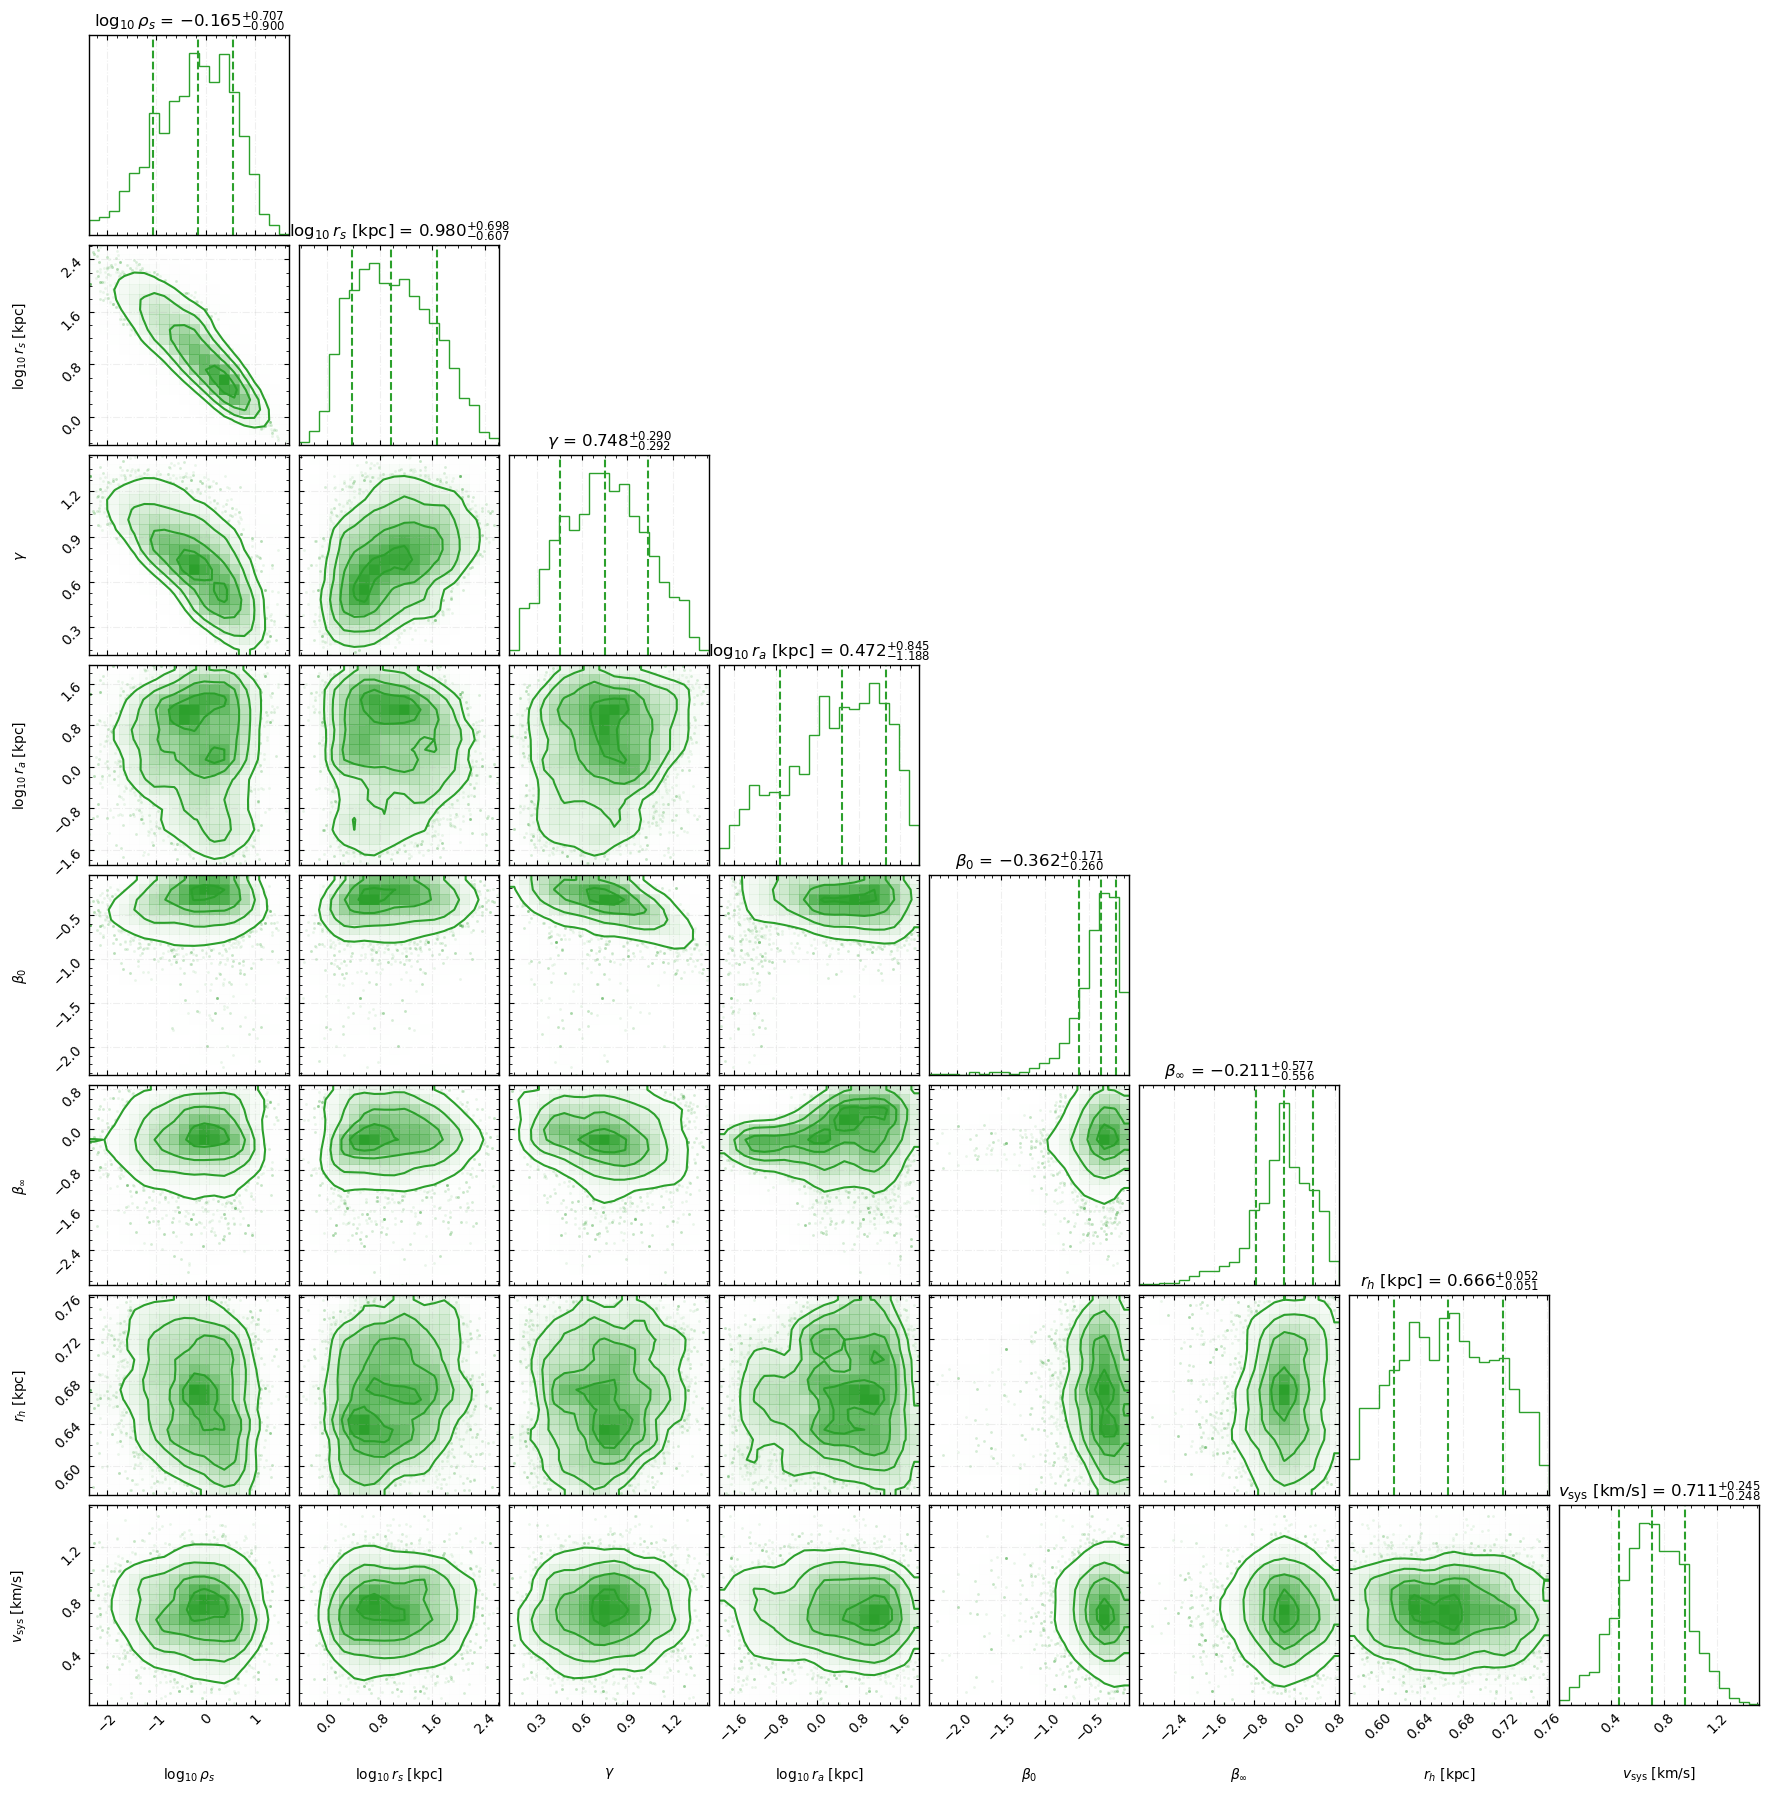

In [10]:
import corner

# save samples
np.save("samples_gen_om.npy", samples_gen_om)

# Convert 2^beta samples to beta for plotting
samples_gen_om_plot = samples_gen_om.copy()
samples_gen_om_plot[:, 4] = np.log2(samples_gen_om[:, 4])  # 2^beta_0 -> beta_0
samples_gen_om_plot[:, 5] = np.log2(samples_gen_om[:, 5])  # 2^beta_inf -> beta_inf

fig = corner.corner(
    samples_gen_om_plot,
    labels=[
        r"$\log_{10}\rho_s$",
        r"$\log_{10}r_s$ [kpc]",
        r"$\gamma$",
        r"$\log_{10}r_a$ [kpc]",
        r"$\beta_0$",
        r"$\beta_\infty$",
        r"$r_h$ [kpc]",
        r"$v_\mathrm{sys}$ [km/s]",
    ],
    quantiles=[0.16, 0.5, 0.84],
    truth_color='k',
    color='C2',
    show_titles=True,
    smooth=1.0,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
)

plt.savefig("corner_gen_om.png", dpi=300)

In [6]:
# Compute posterior profiles
r_plot = np.logspace(-2, 2, 50)
num_max_samples = 500
samples_choice_gen_om = np.random.choice(
    samples_gen_om.shape[0], size=num_max_samples, replace=False)

rho_dm_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))
mass_dm_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))
vdisp_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))
beta_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))

for i, theta_sample in enumerate(samples_gen_om[samples_choice_gen_om]):
    model = GeneralizedOMJeans(theta_sample, min_radius=0.01, max_radius=100, n_radius=50)
    rho_dm_samples_gen_om[i] = model.rho(r_plot)
    mass_dm_samples_gen_om[i] = model.M(r_plot)
    vdisp_samples_gen_om[i] = np.sqrt(model.sigma2_los())
    beta_samples_gen_om[i] = [model.beta(r) for r in r_plot]

NameError: name 'GeneralizedOMJeans' is not defined

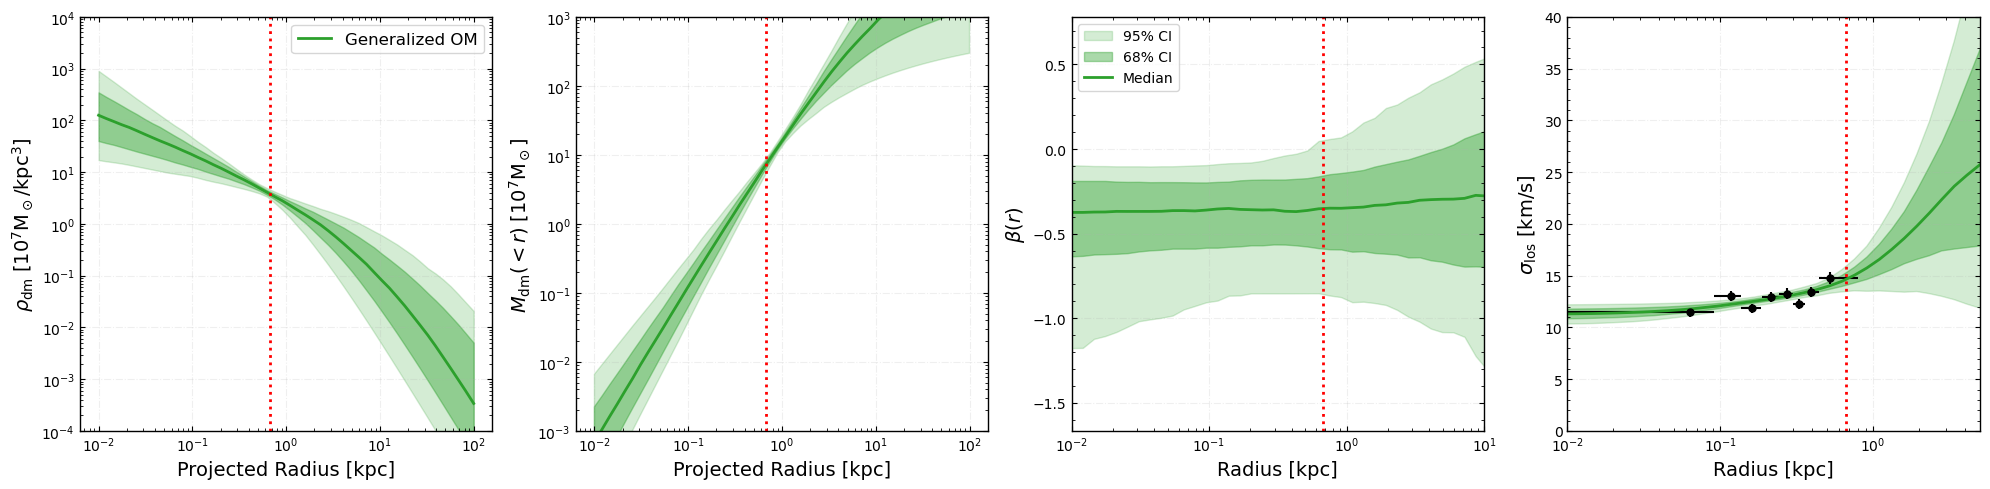

In [12]:
percentiles = [2, 16, 50, 84, 98]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), tight_layout=True)

# ---- Dark Matter Density Profile ----
ax = axes[0]
rho_dm_q = np.percentile(rho_dm_samples_gen_om, percentiles, axis=0)
ax.fill_between(r_plot, rho_dm_q[0], rho_dm_q[4], color='C2', alpha=0.2)
ax.fill_between(r_plot, rho_dm_q[1], rho_dm_q[3], color='C2', alpha=0.4)
ax.plot(r_plot, rho_dm_q[2], color='C2', linestyle='-', lw=2, label='Generalized OM')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_ylim(1e-4, 1e4)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Projected Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$\rho_\mathrm{dm} \; [10^7 \mathrm{M_\odot/kpc^3}]$', fontsize=14)
ax.legend(fontsize=12)

# ---- Enclosed Mass Profile ----
ax = axes[1]
mass_dm_q = np.percentile(mass_dm_samples_gen_om, percentiles, axis=0)
ax.fill_between(r_plot, mass_dm_q[0], mass_dm_q[4], color='C2', alpha=0.2)
ax.fill_between(r_plot, mass_dm_q[1], mass_dm_q[3], color='C2', alpha=0.4)
ax.plot(r_plot, mass_dm_q[2], color='C2', linestyle='-', lw=2, label='Generalized OM')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_ylim(1e-3, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Projected Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$M_\mathrm{dm}(<r) \; [10^7 \mathrm{M_\odot}]$', fontsize=14)

# ---- Beta Profile ----
ax = axes[2]
beta_q = np.percentile(beta_samples_gen_om, percentiles, axis=0)
ax.fill_between(r_plot, beta_q[0], beta_q[4], color='C2', alpha=0.2, label='95% CI')
ax.fill_between(r_plot, beta_q[1], beta_q[3], color='C2', alpha=0.4, label='68% CI')
ax.plot(r_plot, beta_q[2], color='C2', linestyle='-', lw=2, label='Median')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_xlim(0.01, 10)
ax.set_xscale('log')
ax.set_xlabel('Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$\beta(r)$', fontsize=14)
ax.legend(fontsize=10)

# ---- Velocity Dispersion Profile ----
ax = axes[3]
ax.errorbar(
    R_mid, sigma,
    yerr=[sigma_em, sigma_ep],
    xerr=[R_em, R_ep],
    fmt='o', color='black',
    markersize=5, label='Binned Data'
)
vdisp_q = np.percentile(vdisp_samples_gen_om, percentiles, axis=0)
ax.fill_between(r_plot, vdisp_q[0], vdisp_q[4], color='C2', alpha=0.2)
ax.fill_between(r_plot, vdisp_q[1], vdisp_q[3], color='C2', alpha=0.4)
ax.plot(r_plot, vdisp_q[2], color='C2', linestyle='-', lw=2, label='Generalized OM')
ax.axvline(r_half_kpc, color='red', linestyle=':', lw=2)
ax.set_xscale('log')
ax.set_xlabel('Radius [kpc]', fontsize=14)
ax.set_ylabel(r'$\sigma_\mathrm{los}$ [km/s]', fontsize=14)
ax.set_xlim(0.01, 5)
ax.set_ylim(0, 40)
plt.savefig("dispersion_profile_gen_om.png", dpi=300)

In [13]:
idx = np.argmin(np.abs(r_plot - r_half_kpc))
mass_dm_q[2][idx]

np.float64(6.209105100577288)

In [11]:
samples_gen_om = np.load("samples_gen_om.npy")

num_max_samples = 500
samples_choice_gen_om = np.random.choice(
    samples_gen_om.shape[0], size=num_max_samples, replace=False)

rho_dm_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))
mass_dm_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))
beta_samples_gen_om = np.zeros((num_max_samples, len(r_plot)))

for i, theta_sample in enumerate(samples_gen_om[samples_choice_gen_om]):
    model = GeneralizedOMJeans(theta_sample, min_radius=0.01, max_radius=100, n_radius=50)
    rho_dm_samples_gen_om[i] = model.rho(r_plot)
    mass_dm_samples_gen_om[i] = model.M(r_plot)
    beta_samples_gen_om[i] = [model.beta(r) for r in r_plot]

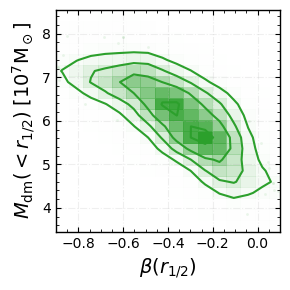

In [22]:
import corner
fig, ax = plt.subplots(figsize=(3, 3), tight_layout=False)

idx_rhalf = np.argmin(np.abs(r_plot - r_half_kpc))
mass_at_rhalf = mass_dm_samples_gen_om[:, idx_rhalf]
beta_at_rhalf = beta_samples_gen_om[:, idx_rhalf]

corner.hist2d(
    beta_at_rhalf, mass_at_rhalf,
    ax=ax,
    color='C2',
    quantiles=[0.16, 0.5, 0.84],
    truth_color='k',
    show_titles=True,
    smooth=1.0,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
    
)

ax.set_xlabel(r'$\beta(r_{1/2})$', fontsize=14)
ax.set_ylabel(r'$M_\mathrm{dm}(<r_{1/2}) \; [10^7 \mathrm{M_\odot}]$', fontsize=14)
# ax.set_title('Posterior: Anisotropy vs Enclosed Mass at $r_{1/2}$', fontsize=14)
ax.set_xlim(-0.9, 0.1)
plt.savefig("beta_mass_contour_gen_om.png", dpi=300)
plt.show()